In [2]:
import yfinance as yf
from pandas_datareader import data as pdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
# Set style for better plots
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [4]:
print("=" * 60)
print("STEP 1: DATA COLLECTION & PREPROCESSING")
print("=" * 60)

# 1. DEFINE DATE RANGE

START_DATE = "2007-01-01"  # Captures 2008 crisis
END_DATE = "2024-12-31"    # Recent data

print(f"\n📅 Date Range: {START_DATE} to {END_DATE}")

STEP 1: DATA COLLECTION & PREPROCESSING

📅 Date Range: 2007-01-01 to 2024-12-31


In [5]:
# 2. LOAD EQUITY MARKET DATA (yfinance)
print("\n📈 Loading equity market data...")

# Define all tickers to download
tickers = {
    # Core market indicators
    '^GSPC': 'sp500',              # S&P 500 Index - broad market performance
    '^VIX': 'vix',                 # Volatility Index - market fear gauge

    # Sector-specific stress indicators
    'HYG': 'high_yield_bonds',     # Credit stress - corporate bond market
    'XLF': 'financials_sector',    # Financial sector - banking system health
    'GLD': 'gold'                  # Safe haven demand - flight to quality
}

equity_data = {}
for ticker, name in tickers.items():
    print(f"   Downloading {name.upper()}...")

    # Download historical data from Yahoo Finance
    df_temp = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

    # Extract Close price column
    # Note: yfinance returns multi-level columns when downloading single ticker
    # Format: ('Close', '^GSPC'), so we use iloc[:,0] to get the actual series
    equity_data[name] = df_temp['Close'].iloc[:, 0]

# Combine all equity data into single DataFrame with aligned dates
df_equity = pd.DataFrame(equity_data)
print(f"✅ Equity data loaded: {df_equity.shape[0]} rows")


📈 Loading equity market data...
✅ Equity data loaded: 4529 rows


In [6]:
# 3. LOAD BOND/TREASURY DATA (FRED)

print("\n📊 Loading Treasury yield data from FRED...")

fred_tickers = {
    'DGS10': 'treasury_10y',    # 10-Year Treasury
    'DGS2': 'treasury_2y',      # 2-Year Treasury
    'DGS3MO': 'treasury_3m',    # 3-Month Treasury
}

bond_data = {}
for ticker, name in fred_tickers.items():
    print(f"   Downloading {name.upper()}...")
    try:
        df = pdr.DataReader(ticker, 'fred', start=START_DATE, end=END_DATE)
        bond_data[name] = df[ticker]
    except Exception as e:
        print(f"   ⚠️ Warning: Could not load {name}: {e}")

df_bonds = pd.DataFrame(bond_data)

print(f"✅ Bond data loaded: {df_bonds.shape[0]} rows")


📊 Loading Treasury yield data from FRED...
✅ Bond data loaded: 4697 rows


In [7]:
# 4. LOAD CREDIT SPREAD DATA (FRED)

print("\n💳 Loading credit spread data from FRED...")

try:
    # BAA Corporate Bond Yield minus 10-Year Treasury
    credit_spread = pdr.DataReader('BAA10Y', 'fred', start=START_DATE, end=END_DATE)
    df_credit = credit_spread.rename(columns={'BAA10Y': 'credit_spread'})
    print(f"✅ Credit spread loaded: {df_credit.shape[0]} rows")
except Exception as e:
    print(f"⚠️ Warning: Could not load credit spread: {e}")
    df_credit = pd.DataFrame()


💳 Loading credit spread data from FRED...
✅ Credit spread loaded: 4697 rows


In [8]:
# 5. MERGE ALL DATASETS

print("\n🔗 Merging all datasets...")

# Start with equity data
df = df_equity.copy()

# Merge bonds
df = df.join(df_bonds, how='outer')

# Merge credit spread
if not df_credit.empty:
    df = df.join(df_credit, how='outer')

print(f"✅ Combined dataset shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")


🔗 Merging all datasets...
✅ Combined dataset shape: (4697, 9)
   Columns: ['sp500', 'vix', 'high_yield_bonds', 'financials_sector', 'gold', 'treasury_10y', 'treasury_2y', 'treasury_3m', 'credit_spread']


In [9]:
# 6. APPLY BUSINESS DAY FREQUENCY

print("\n📆 Applying business day frequency (removing weekends)...")

# Ensure index is datetime
df.index = pd.to_datetime(df.index)

# Reindex to business days only
df = df.asfreq('B')  # 'B' = business day frequency

print(f"✅ Business day frequency applied")
print(f"   Shape after reindex: {df.shape}")


📆 Applying business day frequency (removing weekends)...
✅ Business day frequency applied
   Shape after reindex: (4697, 9)


In [10]:
# 7. HANDLE MISSING VALUES

print("\n🔧 Handling missing values...")

# Check missing values before
missing_before = df.isnull().sum()
print("\nMissing values BEFORE handling:")
print(missing_before[missing_before > 0])

# Strategy:
# - Equity data (trades daily): interpolate
# - Bond/credit data (updates less frequently): forward-fill then interpolate

# Forward fill first (for data that doesn't update daily)
df = df.fillna(method='ffill')

# Then interpolate any remaining gaps
df = df.interpolate(method='linear', limit_direction='both')

# Check missing values after
missing_after = df.isnull().sum()
print("\nMissing values AFTER handling:")
if missing_after.sum() == 0:
    print("✅ No missing values!")
else:
    print(missing_after[missing_after > 0])
    # Drop any remaining NaN rows
    df = df.dropna()
    print(f"⚠️ Dropped {missing_after.sum()} rows with remaining NaN")

print(f"\n✅ Final clean dataset shape: {df.shape}")


🔧 Handling missing values...

Missing values BEFORE handling:
sp500                168
vix                  168
high_yield_bonds     235
financials_sector    168
gold                 168
treasury_10y         193
treasury_2y          193
treasury_3m          193
credit_spread        197
dtype: int64

Missing values AFTER handling:
✅ No missing values!

✅ Final clean dataset shape: (4697, 9)


/tmp/ipython-input-3872837668.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [11]:
# 8. BASIC STATISTICS

print("\n" + "=" * 60)
print("📊 DATASET SUMMARY")
print("=" * 60)

print("\nFirst few rows:")
print(df.head())

print("\nLast few rows:")
print(df.tail())

print("\nBasic statistics:")
print(df.describe())

print("\nData types:")
print(df.dtypes)

print(f"\nDate range: {df.index.min()} to {df.index.max()}")
print(f"Total trading days: {len(df)}")


📊 DATASET SUMMARY

First few rows:
                  sp500    vix  high_yield_bonds  financials_sector  \
2007-01-01  1416.599976  12.04         32.335133          20.661730   
2007-01-02  1416.599976  12.04         32.335133          20.661730   
2007-01-03  1416.599976  12.04         32.335133          20.661730   
2007-01-04  1418.339966  11.51         32.335133          20.594566   
2007-01-05  1409.709961  12.14         32.335133          20.432281   

                 gold  treasury_10y  treasury_2y  treasury_3m  credit_spread  
2007-01-01  62.279999          4.68         4.80         5.07           1.64  
2007-01-02  62.279999          4.68         4.80         5.07           1.64  
2007-01-03  62.279999          4.67         4.76         5.05           1.61  
2007-01-04  61.650002          4.62         4.71         5.04           1.62  
2007-01-05  60.169998          4.65         4.76         5.05           1.60  

Last few rows:
                  sp500    vix  high_yield_bond


📈 Generating visualizations...
✅ Saved visualization: data_overview.png


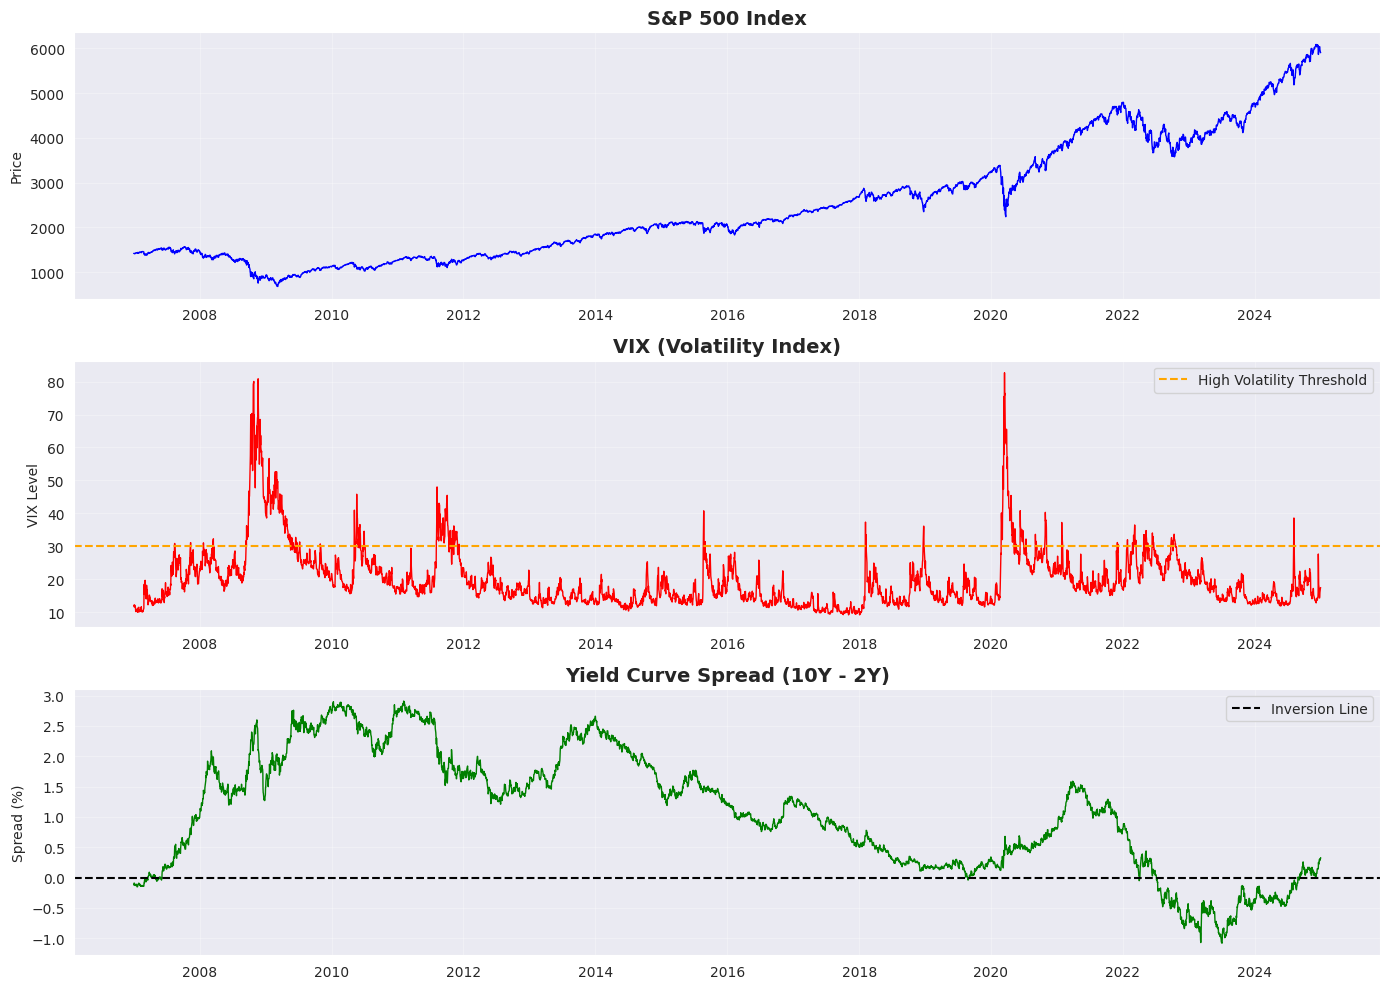

In [12]:
# 9. VISUALIZE RAW DATA

print("\n📈 Generating visualizations...")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: S&P 500
axes[0].plot(df.index, df['sp500'], color='blue', linewidth=1)
axes[0].set_title('S&P 500 Index', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

# Plot 2: VIX
axes[1].plot(df.index, df['vix'], color='red', linewidth=1)
axes[1].set_title('VIX (Volatility Index)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('VIX Level')
axes[1].axhline(y=30, color='orange', linestyle='--', label='High Volatility Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Yield Curve Spread (if available)
if 'treasury_10y' in df.columns and 'treasury_2y' in df.columns:
    yield_spread = df['treasury_10y'] - df['treasury_2y']
    axes[2].plot(df.index, yield_spread, color='green', linewidth=1)
    axes[2].set_title('Yield Curve Spread (10Y - 2Y)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Spread (%)')
    axes[2].axhline(y=0, color='black', linestyle='--', label='Inversion Line')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data_overview.png', dpi=300, bbox_inches='tight')
print("✅ Saved visualization: data_overview.png")
plt.show()

In [13]:
# 10. SAVE CLEAN DATASET

print("\n💾 Saving clean dataset...")

output_file = 'financial_data_clean.csv'
df.to_csv(output_file)
print(f"✅ Saved to: {output_file}")

# 11. FINAL VERIFICATION

print("\n" + "=" * 60)
print("✅ STEP 1 COMPLETE!")
print("=" * 60)
print(f"""
Summary:
- Date range: {df.index.min().date()} to {df.index.max().date()}
- Total rows: {len(df)}
- Features: {len(df.columns)}
- Missing values: {df.isnull().sum().sum()}
- Output file: {output_file}


SyntaxError: incomplete input (ipython-input-2479718735.py, line 14)

In [ ]:
# ============================================================
# STEP 2: FEATURE ENGINEERING - STRESS SIGNALS
# ============================================================
print("\n" + "=" * 60)
print("STEP 2: CREATING STRESS FEATURES")
print("=" * 60)

# Make a copy to preserve original data
df_features = df.copy()

In [ ]:
# ============================================================
# 1. MARKET RETURNS (Basic momentum)
# ============================================================
print("\n📊 Creating return features...")

# Daily returns for S&P 500
# Why: Negative returns indicate market decline
df_features['sp500_return_1d'] = df_features['sp500'].pct_change()

# 5-day return (weekly approximation)
# Why: Captures short-term trend, smooths daily noise
df_features['sp500_return_5d'] = df_features['sp500'].pct_change(periods=5)

# 20-day return (monthly approximation)
# Why: Medium-term trend, stress often builds over weeks
df_features['sp500_return_20d'] = df_features['sp500'].pct_change(periods=20)

print("✅ Return features created")

# ============================================================
# 2. VOLATILITY REGIME (Fear gauge)
# ============================================================
print("\n📈 Creating volatility features...")

# Rolling volatility (20-day window)
# Why: Realized volatility measures actual market choppiness
# High volatility = uncertain/stressed conditions
df_features['sp500_volatility_20d'] = (
    df_features['sp500_return_1d'].rolling(window=20).std() * np.sqrt(252)
)

# VIX percentile (relative to past year)
# Why: Is current fear high compared to recent history?
# Percentile > 80 = elevated fear
df_features['vix_percentile_252d'] = (
    df_features['vix'].rolling(window=252).rank(pct=True) * 100
)

# VIX rate of change (5-day)
# Why: Rapid VIX spikes indicate sudden fear escalation
df_features['vix_change_5d'] = df_features['vix'].pct_change(periods=5)

print("✅ Volatility features created")

# ============================================================
# 3. YIELD CURVE (Recession warning)
# ============================================================
print("\n📉 Creating yield curve features...")

if 'treasury_10y' in df_features.columns and 'treasury_2y' in df_features.columns:
    # Yield curve slope (10Y - 2Y)
    # Why: Inversion (negative slope) historically precedes recessions
    # Normal: ~1-2%, Flat: ~0%, Inverted: negative
    df_features['yield_curve_slope'] = (
        df_features['treasury_10y'] - df_features['treasury_2y']
    )

    # Slope change (20-day)
    # Why: Rapid flattening signals deteriorating growth expectations
    df_features['yield_curve_slope_change_20d'] = (
        df_features['yield_curve_slope'].diff(periods=20)
    )

    print("✅ Yield curve features created")
else:
    print("⚠️ Yield curve features skipped (missing data)")

# ============================================================
# 4. CREDIT SPREAD (Corporate stress)
# ============================================================
print("\n💳 Creating credit spread features...")

if 'credit_spread' in df_features.columns:
    # Credit spread level
    # Why: Already loaded - widening spreads = rising default risk
    # Normal: ~2%, Stressed: >4%, Crisis: >6%

    # Credit spread change (20-day)
    # Why: Acceleration in spread widening = deteriorating credit conditions
    df_features['credit_spread_change_20d'] = (
        df_features['credit_spread'].diff(periods=20)
    )

    # Credit spread percentile (1-year)
    # Why: Is corporate risk elevated relative to recent past?
    df_features['credit_spread_percentile_252d'] = (
        df_features['credit_spread'].rolling(window=252).rank(pct=True) * 100
    )

    print("✅ Credit spread features created")
else:
    print("⚠️ Credit spread features skipped (missing data)")

# ============================================================
# 5. DRAWDOWN (Decline severity)
# ============================================================
print("\n📉 Creating drawdown features...")

# Calculate running maximum (peak)
running_max = df_features['sp500'].expanding().max()

# Drawdown from peak (as percentage)
# Why: Large drawdowns (>20%) often signal bear markets
# -5% = normal, -10% = correction, -20%+ = bear market
df_features['sp500_drawdown'] = (
    (df_features['sp500'] - running_max) / running_max * 100
)

# Drawdown duration (days below previous peak)
# Why: Prolonged drawdowns = sustained stress, not just volatility spike
# Count consecutive days below peak
is_at_peak = (df_features['sp500'] >= running_max)
df_features['drawdown_duration'] = (
    (~is_at_peak).groupby(is_at_peak.cumsum()).cumsum()
)

print("✅ Drawdown features created")

# ============================================================
# 6. SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("📊 FEATURE ENGINEERING SUMMARY")
print("=" * 60)

# Count new features
original_cols = df.columns.tolist()
new_cols = [col for col in df_features.columns if col not in original_cols]

print(f"\nOriginal features: {len(original_cols)}")
print(f"New features created: {len(new_cols)}")
print(f"Total features: {len(df_features.columns)}")

print("\n📋 New features:")
for col in new_cols:
    print(f"   • {col}")

# Check for missing values (rolling windows create NaN at start)
print("\n🔧 Handling initial NaN values from rolling windows...")
initial_rows = len(df_features)
df_features = df_features.dropna()
dropped_rows = initial_rows - len(df_features)
print(f"   Dropped {dropped_rows} rows (warmup period)")

print(f"\n✅ Clean feature dataset: {df_features.shape[0]} rows × {df_features.shape[1]} columns")

# Save
output_file = 'financial_data_features.csv'
df_features.to_csv(output_file)
print(f"\n💾 Saved to: {output_file}")

print("\n" + "=" * 60)
print("✅ FEATURE ENGINEERING COMPLETE!")
print("=" * 60)

In [ ]:
# ============================================================
# PREVIEW FEATURES
# ============================================================

print("\n📊 Feature Preview:")
print(df_features[['sp500', 'vix', 'sp500_volatility_20d',
                   'yield_curve_slope', 'sp500_drawdown']].tail(10))

print("\n📈 Feature Statistics:")
print(df_features[new_cols].describe())

In [ ]:
# ============================================================
# STEP 3: STRESS LABELING (3-LEVEL CLASSIFICATION)
# ============================================================
print("\n" + "=" * 60)
print("STEP 3: CREATING STRESS LABELS")
print("=" * 60)

# Initialize all as Normal (0)
df_features['stress_level'] = 0

# ============================================================
# DEFINE CRISIS LEVEL (2) - Most Severe
# ============================================================
# Financial Reasoning:
# - VIX > 30: Historically marks severe market fear (80th+ percentile typically)
# - Drawdown < -15%: Sustained significant equity decline (beyond correction territory)
# - BOTH conditions required: Reduces false alarms from single-indicator spikes
# - Examples captured: 2008 financial crisis, COVID crash, severe corrections

crisis_mask = (
    (df_features['vix'] > 30) &
    (df_features['sp500_drawdown'] < -15)
)

df_features.loc[crisis_mask, 'stress_level'] = 2

print("\n🚨 CRISIS conditions (Level 2):")
print("   • VIX > 30 (severe fear)")
print("   • Drawdown < -15% (sustained decline)")
print("   • Both must be TRUE (combined signal)")

# ============================================================
# DEFINE ELEVATED LEVEL (1) - Early Warning
# ============================================================
# Financial Reasoning:
# - VIX > 20: Above long-term median, signals rising uncertainty
# - Drawdown < -10%: Standard correction threshold (10%+ decline)
# - Credit spread widening > 0.3%: Indicates deteriorating corporate conditions
# - ANY condition triggers elevated: Early warning system prioritizes sensitivity
# - Excludes already-labeled crisis periods

elevated_mask = (
    (
        (df_features['vix'] > 20) |
        (df_features['sp500_drawdown'] < -10) |
        (df_features['credit_spread_change_20d'] > 0.3)
    ) &
    (df_features['stress_level'] == 0)  # Not already crisis
)

df_features.loc[elevated_mask, 'stress_level'] = 1

print("\n⚠️ ELEVATED conditions (Level 1):")
print("   • VIX > 20 (rising fear) OR")
print("   • Drawdown < -10% (correction) OR")
print("   • Credit spread widening > 0.3% (credit stress)")
print("   • Excludes periods already marked as Crisis")

# ============================================================
# LABEL DISTRIBUTION ANALYSIS
# ============================================================
print("\n" + "=" * 60)
print("📊 STRESS LABEL DISTRIBUTION")
print("=" * 60)

label_counts = df_features['stress_level'].value_counts().sort_index()
label_props = df_features['stress_level'].value_counts(normalize=True).sort_index()

print("\nAbsolute counts:")
for level in [0, 1, 2]:
    count = label_counts.get(level, 0)
    prop = label_props.get(level, 0)
    label_name = ['Normal', 'Elevated', 'Crisis'][level]
    print(f"   {level} ({label_name:8s}): {count:4d} days ({prop*100:5.1f}%)")

print(f"\nTotal days: {len(df_features)}")

# ============================================================
# IDENTIFY KEY CRISIS PERIODS
# ============================================================
print("\n" + "=" * 60)
print("🔍 CRISIS PERIOD VERIFICATION")
print("=" * 60)

crisis_periods = df_features[df_features['stress_level'] == 2]

if len(crisis_periods) > 0:
    print(f"\n✅ Crisis periods identified: {len(crisis_periods)} days")
    print(f"   First crisis day: {crisis_periods.index[0].date()}")
    print(f"   Last crisis day: {crisis_periods.index[-1].date()}")

    # Sample some crisis dates
    print("\n📅 Sample crisis dates:")
    sample_dates = crisis_periods.head(10).index
    for date in sample_dates:
        vix_val = df_features.loc[date, 'vix']
        dd_val = df_features.loc[date, 'sp500_drawdown']
        print(f"   {date.date()}: VIX={vix_val:.1f}, Drawdown={dd_val:.1f}%")

    # Check if major crises captured
    print("\n🎯 Major crisis verification:")

    # 2008 Financial Crisis
    crisis_2008 = crisis_periods[(crisis_periods.index >= '2008-09-01') &
                                  (crisis_periods.index <= '2008-12-31')]
    print(f"   2008 Crisis: {len(crisis_2008)} days labeled")

    # COVID Crash
    crisis_2020 = crisis_periods[(crisis_periods.index >= '2020-02-15') &
                                  (crisis_periods.index <= '2020-04-30')]
    print(f"   COVID Crash: {len(crisis_2020)} days labeled")

    # 2022 Volatility
    crisis_2022 = crisis_periods[(crisis_periods.index >= '2022-01-01') &
                                  (crisis_periods.index <= '2022-06-30')]
    print(f"   2022 Volatility: {len(crisis_2022)} days labeled")

else:
    print("⚠️ No crisis periods identified - check thresholds")

# ============================================================
# CLASS BALANCE CHECK
# ============================================================
print("\n" + "=" * 60)
print("⚖️ CLASS BALANCE ASSESSMENT")
print("=" * 60)

crisis_pct = (label_counts.get(2, 0) / len(df_features)) * 100
elevated_pct = (label_counts.get(1, 0) / len(df_features)) * 100

print(f"\nCrisis class: {crisis_pct:.1f}%")
if crisis_pct < 3:
    print("   ⚠️ Rare class - will need careful train/test split")
elif crisis_pct < 10:
    print("   ✅ Reasonable for rare event modeling")
else:
    print("   ⚠️ May be over-labeling crisis periods")

print(f"\nElevated + Crisis: {crisis_pct + elevated_pct:.1f}%")
if (crisis_pct + elevated_pct) > 40:
    print("   ⚠️ High stress proportion - consider tightening thresholds")
else:
    print("   ✅ Reasonable stress/normal balance")

# ============================================================
# SAVE LABELED DATASET
# ============================================================
output_file = 'financial_data_labeled.csv'
df_features.to_csv(output_file)
print(f"\n💾 Saved labeled dataset: {output_file}")

print("\n" + "=" * 60)
print("✅ STRESS LABELING COMPLETE!")
print("=" * 60)
print("\n📋 Summary:")
print(f"   • 3-level classification system")
print(f"   • Combined signal logic (reduces false positives)")
print(f"   • {len(df_features)} total days labeled")
print(f"   • Ready for train/test split and modeling")

In [ ]:
# ============================================================
# VISUALIZE STRESS LABELS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: S&P 500 with stress overlay
axes[0].plot(df_features.index, df_features['sp500'], color='blue', linewidth=0.8, label='S&P 500')

# Color-code background by stress level
normal_mask = df_features['stress_level'] == 0
elevated_mask = df_features['stress_level'] == 1
crisis_mask = df_features['stress_level'] == 2

axes[0].fill_between(df_features.index, 0, 1, where=elevated_mask,
                      transform=axes[0].get_xaxis_transform(),
                      alpha=0.2, color='orange', label='Elevated')
axes[0].fill_between(df_features.index, 0, 1, where=crisis_mask,
                      transform=axes[0].get_xaxis_transform(),
                      alpha=0.3, color='red', label='Crisis')

axes[0].set_title('S&P 500 with Stress Periods', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: VIX with thresholds
axes[1].plot(df_features.index, df_features['vix'], color='red', linewidth=0.8)
axes[1].axhline(y=20, color='orange', linestyle='--', label='Elevated threshold (20)')
axes[1].axhline(y=30, color='darkred', linestyle='--', label='Crisis threshold (30)')
axes[1].set_title('VIX with Stress Thresholds', fontsize=14, fontweight='bold')
axes[1].set_ylabel('VIX Level')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stress_labels_visualization.png', dpi=300, bbox_inches='tight')
print("✅ Saved: stress_labels_visualization.png")
plt.show()

In [ ]:
# Improved crisis conditions
crisis_mask = (
    # Original: Both high fear AND significant drawdown
    ((df_features['vix'] > 30) & (df_features['sp500_drawdown'] < -15)) |

    # NEW: Extreme VIX alone (captures flash crashes)
    (df_features['vix'] > 45) |

    # NEW: Rapid VIX escalation (captures building panic)
    ((df_features['vix'] > 30) & (df_features['vix_change_5d'] > 0.3))
)

df_features.loc[crisis_mask, 'stress_level'] = 2

In [ ]:
# ============================================================
# VISUALIZE STRESS LABELS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: S&P 500 with stress overlay
axes[0].plot(df_features.index, df_features['sp500'], color='blue', linewidth=0.8, label='S&P 500')

# Color-code background by stress level
normal_mask = df_features['stress_level'] == 0
elevated_mask = df_features['stress_level'] == 1
crisis_mask = df_features['stress_level'] == 2

axes[0].fill_between(df_features.index, 0, 1, where=elevated_mask,
                      transform=axes[0].get_xaxis_transform(),
                      alpha=0.2, color='orange', label='Elevated')
axes[0].fill_between(df_features.index, 0, 1, where=crisis_mask,
                      transform=axes[0].get_xaxis_transform(),
                      alpha=0.3, color='red', label='Crisis')

axes[0].set_title('S&P 500 with Stress Periods', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: VIX with thresholds
axes[1].plot(df_features.index, df_features['vix'], color='red', linewidth=0.8)
axes[1].axhline(y=20, color='orange', linestyle='--', label='Elevated threshold (20)')
axes[1].axhline(y=30, color='darkred', linestyle='--', label='Crisis threshold (30)')
axes[1].set_title('VIX with Stress Thresholds', fontsize=14, fontweight='bold')
axes[1].set_ylabel('VIX Level')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stress_labels_visualization.png', dpi=300, bbox_inches='tight')
print("✅ Saved: stress_labels_visualization.png")
plt.show()